In [3]:
!pip install arch pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 37.2 MB/s eta 0:00:00


--- 1. CARICAMENTO DATI ---
--- 2. FITTING MODELLO (GJR-GARCH + DCC) ---
>> Fitting Univariate Models...
>> Estimating DCC Parameters...

[DCC PARAMS] a=0.0072, b=0.9870 (Sum: 0.9942)

--- 3. CALCOLO FORECAST (5 GIORNI) ---

>>> PREVISIONE VOLATILITÀ (%):
     Price1  Price2  Price3
T+1   2.358   3.106   1.894
T+2   2.350   3.298   1.909
T+3   2.343   3.355   1.922
T+4   2.337   3.371   1.933
T+5   2.333   3.377   1.944

>>> PREVISIONE CORRELAZIONI:
Coppia Price1-Price2: [0.3983 0.3978 0.3973 0.3968 0.3963]
Coppia Price1-Price3: [0.3591 0.3591 0.3592 0.3592 0.3592]
Coppia Price2-Price3: [0.1859 0.1863 0.1867 0.1871 0.1875]

--- 4. VISUALIZZAZIONE GRAFICA ---


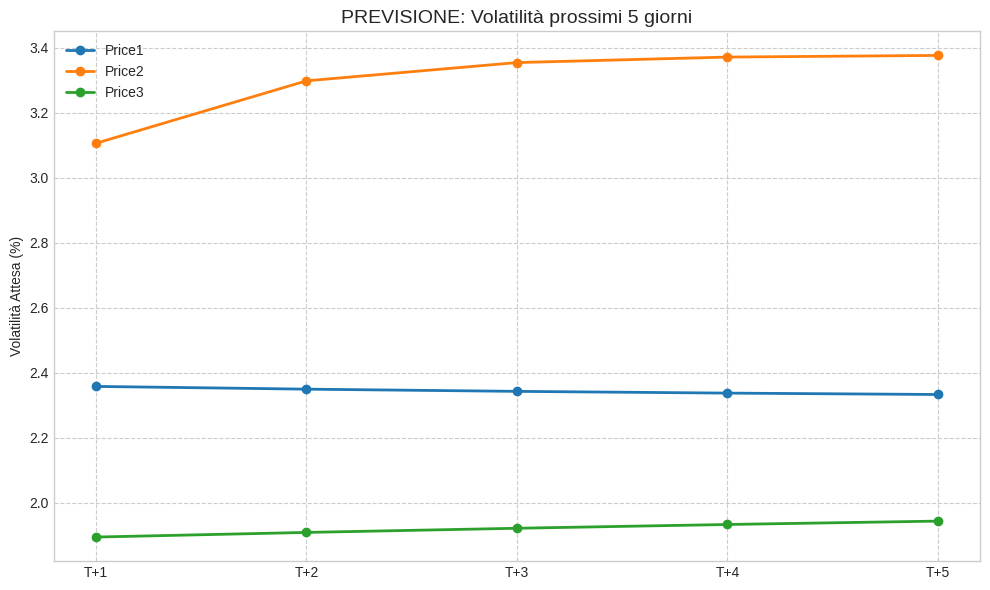

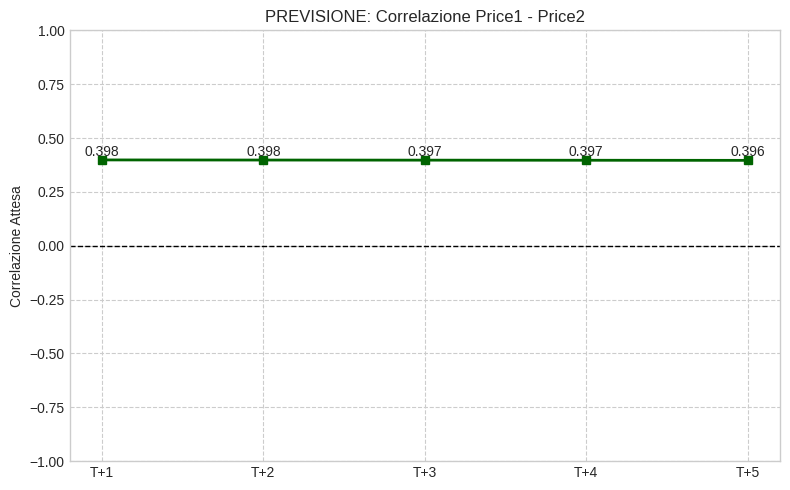

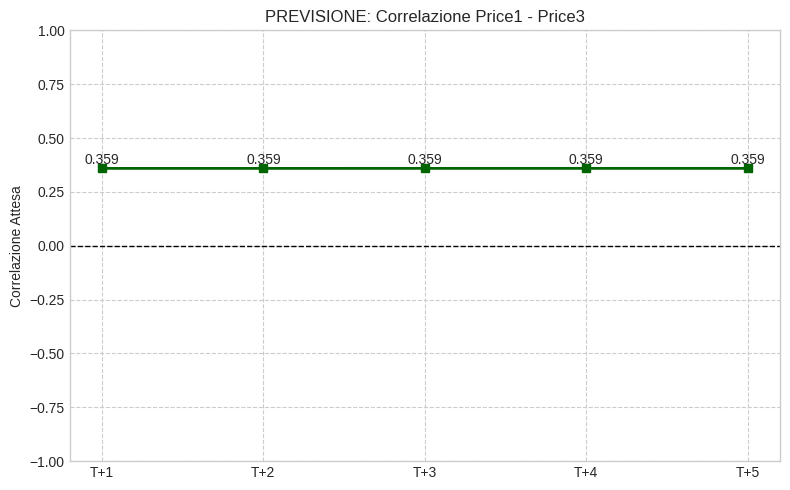

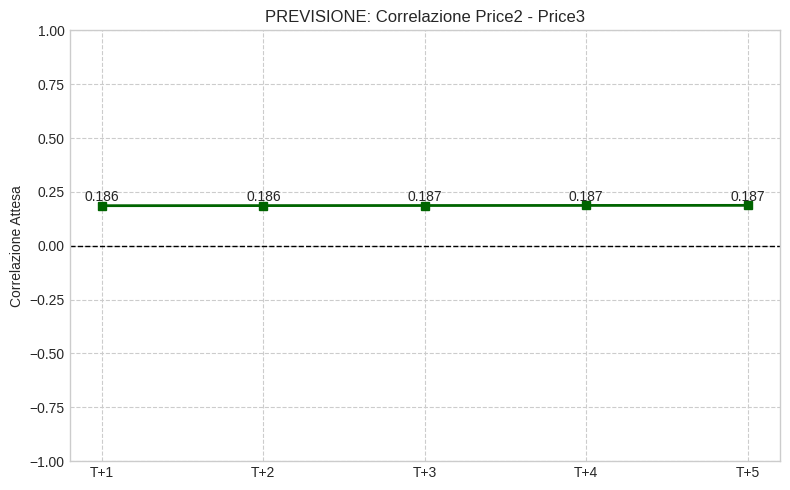

In [5]:
"""
Integrated Multivariate DCC-GARCH Modelling Script.
Input: Excel File 'Zeri_Tommaso.xlsx' (Sheet: Ex.2)
Features:
 - GJR-GARCH(1,1) Univariato
 - DCC(1,1) Multivariato
 - Forecast a 5 giorni con Grafici dedicati
"""
from __future__ import annotations

import os
from itertools import combinations
from typing import Tuple

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from arch.univariate.base import ARCHModelResult
from arch.univariate.mean import ZeroMean
from arch.univariate.volatility import GARCH
from numpy.linalg import det, inv
from pmdarima.arima import ARIMA
from scipy.optimize import minimize


In [ ]:
# --- CLASS 1: UGARCH (Univariate GARCH) ---
class UGARCH:
    """Univariate GARCH volatility modelling (GJR-GARCH specification)."""

    def __init__(self, order: tuple[int, int] = (1, 1)) -> None:
        self.order = order
        self.order_p, self.order_q = self.order
        self._returns: np.ndarray = None
        self.asset: str = None
        self.mean_model: ARIMA = None
        self.vol_model: GARCH = None
        self.fitted_mean_model: ARIMA = None
        self.fitted_vol_model: ARCHModelResult = None
        self.cond_vol: np.ndarray = None
        self.std_resid: np.ndarray = None
        self.fc_means: np.ndarray = None
        self.fc_vol: np.ndarray = None
        self.n_ahead: int = None

    @property
    def returns(self) -> np.ndarray:
        return self._returns

    @returns.setter
    def returns(self, returns: pd.Series) -> None:
        self._returns = returns.to_numpy()
        self.asset = returns.name
        self.dates = returns.index

    def spec(self, returns: pd.Series) -> None:
        self.returns = returns
        self.mean_model = ARIMA(order=(self.order_p, 0, self.order_q))
        self.vol_model = GARCH(p=self.order_p, o=self.order_p, q=self.order_q)

    def fit(self) -> None:
        self.fitted_mean_model = self.mean_model.fit(self.returns)
        arma_resids = self.fitted_mean_model.resid()

        self.fitted_vol_model = ZeroMean(
            y=arma_resids,
            volatility=self.vol_model,
        ).fit(disp="off")

        self.std_resid = self.fitted_vol_model.std_resid
        self.cond_vol = self.fitted_vol_model.conditional_volatility

    def forecast(self, n_ahead: int) -> None:
        self.n_ahead = n_ahead
        self.fc_means = self.fitted_mean_model.predict(n_periods=self.n_ahead)
        fc_vol_model = self.fitted_vol_model.forecast(horizon=self.n_ahead, reindex=True)
        # Estrae la varianza prevista per gli ultimi n_ahead step
        # Nota: arch restituisce forecast per ogni data storica, a noi serve l'ultima riga proiettata in avanti
        variance_forecast = fc_vol_model.variance.iloc[-1].values
        self.fc_vol = np.sqrt(variance_forecast)

In [ ]:
# --- CLASS 2: DCCGARCH (Multivariate GARCH) ---
class DCCGARCH:
    """Dynamic Conditional Correlation (DCC) GARCH modelling."""

    def __init__(self) -> None:
        self.assets: list[str] = []
        self.ugarch_objs: list[UGARCH] = []
        self.std_resids: np.ndarray = None
        self.cond_vols: np.ndarray = None
        self.cond_cor: np.ndarray = None
        self.dcc_a: float = None
        self.dcc_b: float = None
        self.fc_vols: np.ndarray = None
        self.fc_cor: np.ndarray = None
        self.n_ahead: int = None

    def spec(self, ugarch_objs: list[UGARCH], returns: pd.DataFrame) -> None:
        self.assets = returns.columns.to_list()
        self.dates = returns.index
        self.ugarch_objs = ugarch_objs
        for i, garch_obj in enumerate(self.ugarch_objs):
            garch_obj.spec(returns.iloc[:, i])

    def fit(self) -> None:
        print(">> Fitting Univariate Models...")
        for garch_obj in self.ugarch_objs:
            garch_obj.fit()

        self.std_resids = np.array([g.std_resid for g in self.ugarch_objs]).T
        self.cond_vols = np.array([g.cond_vol for g in self.ugarch_objs]).T

        print(">> Estimating DCC Parameters...")
        self.estimate_params()

        self.cond_cor, _ = self.dynamic_corr(
            res=self.std_resids,
            cvol=self.cond_vols,
            dcc_a=self.dcc_a,
            dcc_b=self.dcc_b,
        )

    def forecast(self, n_ahead: int) -> None:
        self.n_ahead = n_ahead
        n_assets = len(self.assets)

        # 1. Forecast Univariato
        for garch_obj in self.ugarch_objs:
            garch_obj.forecast(self.n_ahead)

        self.fc_vols = np.array([g.fc_vol for g in self.ugarch_objs]).T

        # 2. Forecast DCC
        R0 = self.cond_cor[:, :, -1]
        Q_bar = np.cov(self.std_resids, rowvar=False)

        self.fc_cor = np.zeros((n_assets, n_assets, self.n_ahead))
        decay = self.dcc_a + self.dcc_b

        for k in range(1, self.n_ahead + 1):
            # Mean Reversion verso la correlazione incondizionata
            weight_long = (1 - decay**k)
            weight_short = (decay**k)
            self.fc_cor[:, :, k - 1] = weight_long * Q_bar + weight_short * R0

    @staticmethod
    def dynamic_corr(res: np.ndarray, cvol: np.ndarray, dcc_a: float, dcc_b: float) -> Tuple[np.ndarray, np.ndarray]:
        n_periods, n_assets = res.shape
        Q_bar = np.cov(res, rowvar=False)

        Q = np.zeros((n_assets, n_assets, n_periods))
        Q[:, :, 0] = Q_bar

        Z = np.zeros((n_assets, n_assets, n_periods))
        for i in range(n_periods):
            Z[:, :, i] = np.outer(res[i, :], res[i, :].T)

        for i in range(1, n_periods):
            Q[:, :, i] = ((1 - dcc_a - dcc_b) * Q_bar + dcc_a * Z[:, :, i - 1] + dcc_b * Q[:, :, i - 1])

        R = np.zeros((n_assets, n_assets, n_periods))
        for i in range(n_periods):
            q_diag = np.diag(Q[:, :, i])
            inv_sqrt_diag = np.diag(1 / np.sqrt(q_diag))
            R[:, :, i] = np.dot(inv_sqrt_diag, np.dot(Q[:, :, i], inv_sqrt_diag))

        return R, None

    @classmethod
    def qllf(cls, params: list[float], args: list) -> float:
        res, cvol = args
        dcc_a, dcc_b = params
        if dcc_a < 0 or dcc_b < 0 or (dcc_a + dcc_b) >= 0.9999:
             return 1e10

        R, _ = cls.dynamic_corr(res=res, cvol=cvol, dcc_a=dcc_a, dcc_b=dcc_b)
        ll = 0
        n_periods = res.shape[0]
        eye = np.eye(R.shape[1])
        for i in range(n_periods):
             try:
                R_reg = R[:, :, i] + eye * 1e-6
                ll += np.log(det(R_reg)) + np.dot(res[i, :].T, np.dot(inv(R_reg), res[i, :]))
             except np.linalg.LinAlgError:
                 return 1e10
        return 0.5 * ll

    def estimate_params(self) -> None:
        constr = [
            {"type": "ineq", "fun": lambda x: 0.9999 - np.sum(x)},
            {"type": "ineq", "fun": lambda x: x[0]},
            {"type": "ineq", "fun": lambda x: x[1]},
        ]
        x0 = [0.05, 0.90]
        solution = minimize(
            fun=self.qllf, x0=x0, args=[self.std_resids, self.cond_vols],
            constraints=constr, method='SLSQP', options={"disp": False},
        )
        self.dcc_a, self.dcc_b = solution.x

    # --- PLOTTING METHODS ---
    def plot_historical(self) -> None:
        """Grafici storici (passato)."""
        plt.style.use('seaborn-v0_8-whitegrid')

        # Volatilità Storica
        for i, asset in enumerate(self.assets):
            plt.figure(figsize=(10, 4))
            plt.plot(self.dates, self.cond_vols[:, i], color='navy', lw=1)
            plt.title(f"STORICO: Volatilità {asset}", fontsize=12, weight='bold')
            plt.ylabel("Volatilità (%)")
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.tight_layout()
            plt.show()

        # Correlazione Storica
        pairs = list(combinations(range(len(self.assets)), 2))
        for i, j in pairs:
            plt.figure(figsize=(10, 4))
            plt.plot(self.dates, self.cond_cor[i, j, :], color='darkred', lw=1)
            plt.title(f"STORICO: Corr {self.assets[i]} - {self.assets[j]}", fontsize=12)
            plt.axhline(0, color='black', linestyle='--')
            plt.ylim(-1, 1)
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.tight_layout()
            plt.show()

    def plot_forecast(self) -> None:
        """Grafici previsione (futuro 5 giorni)."""
        plt.style.use('seaborn-v0_8-whitegrid')
        days = [f"T+{i}" for i in range(1, self.n_ahead + 1)]

        # 1. Plot Forecast Volatilità (Tutti insieme per confronto)
        plt.figure(figsize=(10, 6))
        for i, asset in enumerate(self.assets):
            plt.plot(days, self.fc_vols[:, i], marker='o', label=asset, lw=2)

        plt.title(f"PREVISIONE: Volatilità prossimi {self.n_ahead} giorni", fontsize=14)
        plt.ylabel("Volatilità Attesa (%)")
        plt.grid(True, linestyle='--')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # 2. Plot Forecast Correlazione (Per coppia)
        pairs = list(combinations(range(len(self.assets)), 2))
        for i, j in pairs:
            asset1 = self.assets[i]
            asset2 = self.assets[j]
            corr_fc = self.fc_cor[i, j, :] # Array di lunghezza n_ahead

            plt.figure(figsize=(8, 5))
            plt.plot(days, corr_fc, marker='s', color='darkgreen', lw=2)
            plt.title(f"PREVISIONE: Correlazione {asset1} - {asset2}", fontsize=12)
            plt.ylabel("Correlazione Attesa")
            plt.ylim(-1, 1) # Mantieni scala fissa
            plt.axhline(0, color='black', lw=1, linestyle='--')
            plt.grid(True, linestyle='--')
            for x, y in zip(days, corr_fc):
                plt.text(x, y + 0.02, f"{y:.3f}", ha='center')
            plt.tight_layout()
            plt.show()

In [ ]:
# --- MAIN ---
if __name__ == "__main__":
    file_name = "Zeri_Tommaso.xlsx"
    sheet_name = "Ex.2"

    print(f"--- 1. CARICAMENTO DATI ---")
    if not os.path.exists(file_name):
        print(f"ERRORE: File {file_name} non trovato.")
        exit()

    # Lettura Excel
    raw_df = pd.read_excel(file_name, sheet_name=sheet_name, decimal=',', parse_dates=['Date'])
    raw_df['Date'] = pd.to_datetime(raw_df['Date'], dayfirst=True)
    raw_df.set_index('Date', inplace=True)

    # Prepara Dati
    target_cols = ["Price1", "Price2", "Price3"]
    data = raw_df[target_cols].dropna()
    returns = 100 * np.log(data / data.shift(1)).dropna() # returns in %

    # Fit
    print("--- 2. FITTING MODELLO (GJR-GARCH + DCC) ---")
    ugarch_list = [UGARCH(order=(1, 1)) for _ in range(len(target_cols))]
    dcc = DCCGARCH()
    dcc.spec(ugarch_list, returns)
    dcc.fit()

    print(f"\n[DCC PARAMS] a={dcc.dcc_a:.4f}, b={dcc.dcc_b:.4f} (Sum: {dcc.dcc_a+dcc.dcc_b:.4f})")

    # Forecast
    N_DAYS = 5
    print(f"\n--- 3. CALCOLO FORECAST ({N_DAYS} GIORNI) ---")
    dcc.forecast(n_ahead=N_DAYS)

    # Stampa Tabelle Forecast
    days_labels = [f"T+{i}" for i in range(1, N_DAYS + 1)]

    print("\n>>> PREVISIONE VOLATILITÀ (%):")
    df_vol_fc = pd.DataFrame(dcc.fc_vols, index=days_labels, columns=target_cols)
    print(df_vol_fc.round(3))

    print("\n>>> PREVISIONE CORRELAZIONI:")
    pairs = list(combinations(range(len(target_cols)), 2))
    for i, j in pairs:
        a1, a2 = target_cols[i], target_cols[j]
        vals = dcc.fc_cor[i, j, :]
        print(f"Coppia {a1}-{a2}: {vals.round(4)}")

    # Grafici
    print("\n--- 4. VISUALIZZAZIONE GRAFICA ---")
    # dcc.plot_historical() # Decommenta se vuoi anche i grafici storici
    dcc.plot_forecast()